<div style="display: flex; justify-content: space-between; align-items: center;">

<img src="https://github.com/ctapia16/Analisis-y-Visualizacion/blob/main/logoFIME.jpg?raw=true" width="150"/>

<img src="https://github.com/ctapia16/Analisis-y-Visualizacion/blob/main/logo_ICI.png?raw=true" width="200"/>

</div>

<br>

<h2 style="text-align: center;">
Universidad de Colima
</h2>

<h3 style="text-align: center;">
Facultad de Ingeniería Mecánica y Eléctrica
    </h3>

<h3 style="text-align: center;">
Ingeniería en Computación Inteligente
</h3>

<h3 style="text-align: center;">
Data Analysis and Visualization
</h3>

<h2 style="text-align: center;">
Exploratory Analysis of the Recip Dataset 
</h2>

<br>

<p style="text-align: center;">
<strong>Alumnos:</strong> Carlos Isaac Tapia Gonzalez<br>
<strong>Lugar:</strong> Colima, Colima<br>
<strong>Fecha:</strong> March 2026
</p>

### Introduccion 

In [2]:
#Importar Librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1. Loading Complex Data

In [ ]:
#iMPORTAR LIBRERIAS
df = pd.read_json("train.json")

In [19]:
# Convertir el Dataset.json a Dataset.csv
df.to_csv("cuisineDataset.csv", index=False)
print("Listo: cuisineDataset.csv guardado")

Listo: cuisineDataset.csv guardado


In [6]:
# Explora la estructura
print(df.head())
print(f"\nTotal de recetas: {len(df)}")

      id      cuisine                                        ingredients
0  10259        greek  [romaine lettuce, black olives, grape tomatoes...
1  25693  southern_us  [plain flour, ground pepper, salt, tomatoes, g...
2  20130     filipino  [eggs, pepper, salt, mayonaise, cooking oil, g...
3  22213       indian                [water, vegetable oil, wheat, salt]
4  13162       indian  [black pepper, shallots, cornflour, cayenne pe...

Total de recetas: 39774


## Step 2: "Explode" the lists (Data Transformation)

In [5]:
# Transformar la columna 'ingredients'
df_ingredients = df.explode('ingredients')

In [7]:
# Test out
print("\nDataset después de aplicar 'explode':")
print(df_ingredients[['id', 'cuisine', 'ingredients']].head(10))


Dataset después de aplicar 'explode':
      id      cuisine           ingredients
0  10259        greek       romaine lettuce
0  10259        greek          black olives
0  10259        greek        grape tomatoes
0  10259        greek                garlic
0  10259        greek                pepper
0  10259        greek          purple onion
0  10259        greek             seasoning
0  10259        greek        garbanzo beans
0  10259        greek  feta cheese crumbles
1  25693  southern_us           plain flour


## Step 3: Identify the "King" Ingredients by Cuisine

In [8]:
# Filtrar por cocina mexicana y contar ingredientes
top_mexican=df_ingredients[df_ingredients['cuisine']=='mexican']['ingredients'].value_counts().head(10)

/tmp/ipykernel_79762/1527876618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mexican.values, y=top_mexican.index, palette='viridis')


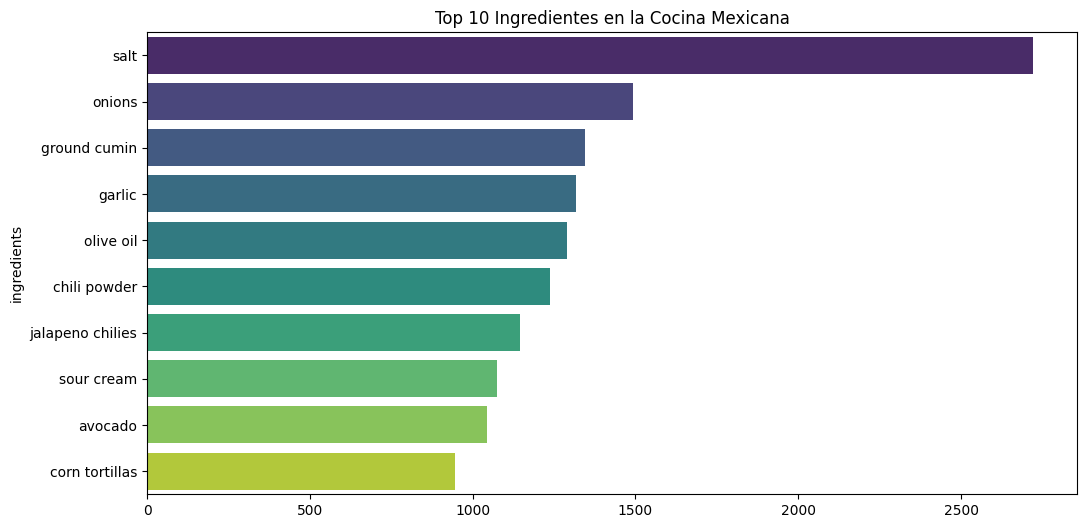

In [9]:
# Graphics
plt.figure(figsize=(12, 6))
sns.barplot(x=top_mexican.values, y=top_mexican.index, palette='viridis')
plt.title('Top 10 Ingredientes en la Cocina Mexicana')
plt.show()

## Step 4: Visualizing Gastronomic Diversity

/tmp/ipykernel_79762/2016538559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='cuisine', order=df['cuisine'].value_counts().index, palette='coolwarm')


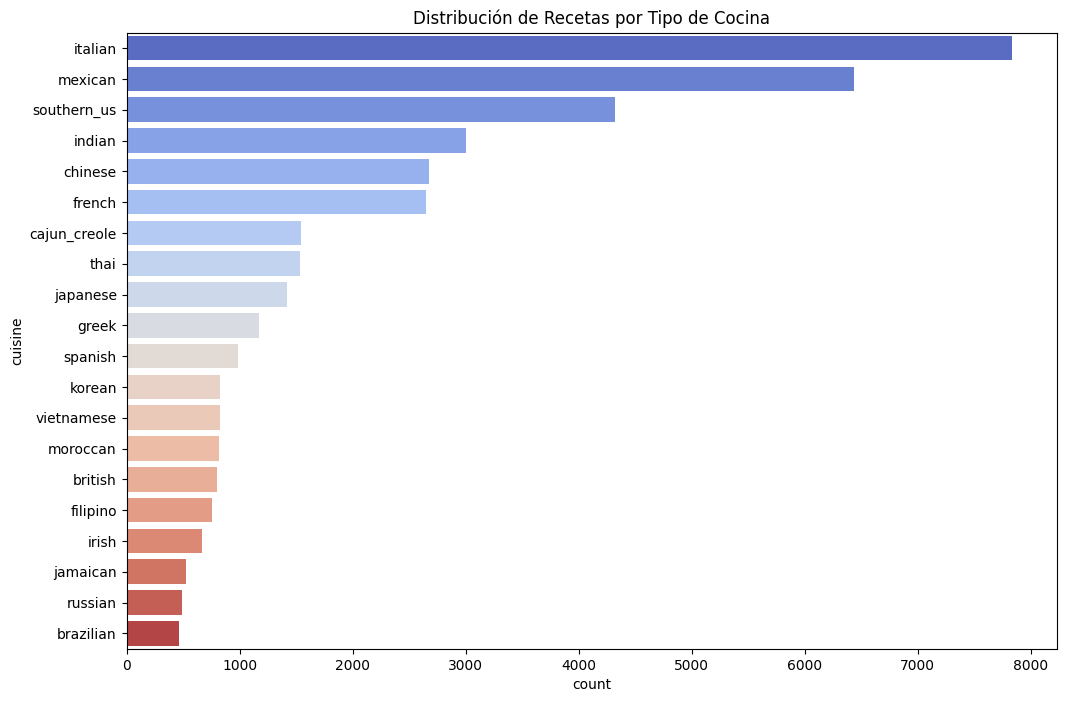

In [10]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='cuisine', order=df['cuisine'].value_counts().index, palette='coolwarm')
plt.title('Distribución de Recetas por Tipo de Cocina')
plt.show()

In [11]:
def ensure_list(x):
    if isinstance(x, list):
        return x
    return x  # lo dejamos igual si no sabemos

df['ingredients'] = df['ingredients'].apply(ensure_list)

df_exploded = df.explode('ingredients').copy()
df_exploded['ingredients'] = df_exploded['ingredients'].astype(str).str.strip().str.lower()

df_exploded.head()

,id,cuisine,ingredients
0,10259,greek,romaine lettuce
0,10259,greek,black olives
0,10259,greek,grape tomatoes
0,10259,greek,garlic
0,10259,greek,pepper


In [13]:
top5_italian = (df_exploded[df_exploded['cuisine'] == 'italian']['ingredients']
                .value_counts()
                .head(5)
                .reset_index())
top5_italian.columns = ['ingredient', 'count']
top5_italian['cuisine'] = 'italian'

top5_japanese = (df_exploded[df_exploded['cuisine'] == 'japanese']['ingredients']
                 .value_counts()
                 .head(5)
                 .reset_index())
top5_japanese.columns = ['ingredient', 'count']
top5_japanese['cuisine'] = 'japanese'

top5_table = pd.concat([top5_italian, top5_japanese], ignore_index=True)
top5_table


,ingredient,count,cuisine
0,salt,3454,italian
1,olive oil,3111,italian
2,garlic cloves,1619,italian
3,grated parmesan cheese,1580,italian
4,garlic,1471,italian
5,soy sauce,561,japanese
6,salt,422,japanese
7,mirin,402,japanese
8,sugar,401,japanese
9,water,383,japanese


In [14]:
top5_pivot = top5_table.copy()
top5_pivot['rank'] = top5_pivot.groupby('cuisine')['count'].rank(method='first', ascending=False).astype(int)
top5_pivot = top5_pivot.pivot(index='rank', columns='cuisine', values=['ingredient', 'count'])
top5_pivot

ingredient              count         
cuisine                 italian   japanese italian japanese
rank                                                       
1                          salt  soy sauce    3454      561
2                     olive oil       salt    3111      422
3                 garlic cloves      mirin    1619      402
4        grated parmesan cheese      sugar    1580      401
5                        garlic      water    1471      383

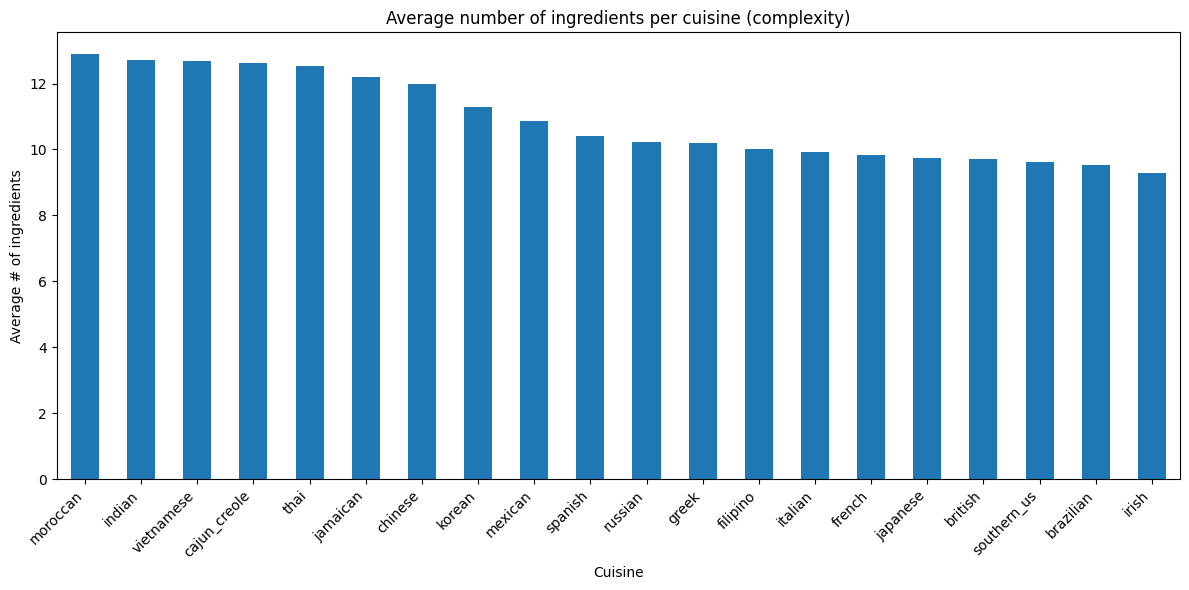

cuisine
moroccan        12.909866
indian          12.705961
vietnamese      12.675152
cajun_creole    12.617076
thai            12.545809
jamaican        12.214829
chinese         11.982791
korean          11.284337
mexican         10.877446
spanish         10.423660
Name: n_ingredients, dtype: float64

In [15]:
df['n_ingredients'] = df['ingredients'].apply(lambda x: len(x) if isinstance(x, list) else 0)

avg_by_cuisine = (df.groupby('cuisine')['n_ingredients']
                  .mean()
                  .sort_values(ascending=False))

plt.figure(figsize=(12,6))
avg_by_cuisine.plot(kind='bar')
plt.title('Average number of ingredients per cuisine (complexity)')
plt.xlabel('Cuisine')
plt.ylabel('Average # of ingredients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

avg_by_cuisine.head(10)

In [16]:
# 1) Ingrediente más común en todo el dataset
most_common_ingredient = df_exploded['ingredients'].value_counts().idxmax()
most_common_count = df_exploded['ingredients'].value_counts().max()

most_common_ingredient, most_common_count

('salt', np.int64(18049))

## Preguntas del estudiante

**1) ¿Cuál es el ingrediente más común en todo el dataset?**  
Después de analizar todo el dataset y aplicar explode a la columna de ingredientes, encontramos que el ingrediente más común es **salt**, apareciendo un total de **18049 veces**. Esto tiene sentido porque es un ingrediente básico que se usa prácticamente en cualquier tipo de cocina.

**2) ¿Qué pasa si intentamos recomendar una cuisine usando solo un ingrediente como “water” o “salt”?**  
Nos dimos cuenta de que ingredientes como “water” o “salt” aparecen en demasiadas recetas y en casi todos los tipos de cocina. Entonces, si el sistema recomendara solo con base en uno de estos ingredientes, los resultados serían muy generales y poco precisos. Creemos que sería mejor darle menos peso a estos ingredientes comunes o combinarlos con otros más específicos para hacer recomendaciones más acertadas.

**3) ¿Por qué no se puede usar value_counts() directamente en la columna original de ingredientes?**  
No se puede usar directamente porque la columna original contiene listas de ingredientes por receta, no valores individuales. Primero tuvimos que usar explode() para separar cada ingrediente en una fila diferente y así poder contar correctamente la frecuencia de cada uno.

## Conclusión

En este análisis trabajamos con un dataset de recetas para identificar los ingredientes más comunes y entender las diferencias entre distintos tipos de cocina. A partir de la limpieza de datos y el uso de explode(), pudimos calcular frecuencias, comparar ingredientes representativos y medir la complejidad promedio de cada cuisine según su número de ingredientes.

Como equipo, consideramos que estos resultados pueden aplicarse directamente en una plataforma como Uber Eats. Por ejemplo, si un usuario busca ciertos ingredientes específicos (como “soy sauce” o “parmesan”), el sistema podría relacionarlos con una cocina determinada y mostrar restaurantes más relevantes. Esto ayudaría a mejorar el sistema de recomendaciones y hacer que las búsquedas sean más personalizadas.

También observamos que ingredientes muy comunes como “salt” o “water” no son buenos indicadores para recomendar una cocina, ya que aparecen en casi todas las recetas. Por eso, en un sistema como Uber Eats sería importante reducir el peso de estos ingredientes dentro del algoritmo para evitar recomendaciones demasiado generales.

En conclusión, este análisis demuestra cómo los datos pueden utilizarse para optimizar motores de búsqueda y recomendación en plataformas de entrega de comida, mejorando la experiencia del usuario y haciendo que encuentre opciones más acordes a sus gustos.